In [1]:
#| output: false
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from trialframe import multivalue_xs, hierarchical_assign, get_index_level, get_epoch_data
from src import crystal_models
from src.io import generic_preproc, get_targets
from sklearn.decomposition import PCA
from omegaconf import DictConfig
%matplotlib inline

In [2]:
args = DictConfig({
    'trialframe_dir': Path('../data/trialframe'),
    'dataset': 'Prez_2025-04-16',
    'composition_config': Path('../conf/trialframe_eye_calib.yaml'),
})

In [37]:
from src.io import load_trial_frame
rtt_hand_eye_tf = (
    load_trial_frame(args)
    .set_index('state', append=True)
    .xs(level='result',key='success')
    .xs(level='task', key='RTT')
    .rename(columns=lambda col: col.replace('eye_',''))
)
rtt_hand_eye_tf

signal                                                                                                                                                 hand position  \
channel                                                                                                                                                            x   
block              trial_id time                   monkey session date trial datetime      trial name                           memory state                           
memory-cst-rtt-dco 6        0 days 00:00:00        Dwight 2025-04-16   2025-04-16 09:27:55 RandomTargetTask-small-reward-memory True   Reach to Center     75.045088   
                            0 days 00:00:00.010000 Dwight 2025-04-16   2025-04-16 09:27:55 RandomTargetTask-small-reward-memory True   Reach to Center     75.229179   
                            0 days 00:00:00.020000 Dwight 2025-04-16   2025-04-16 09:27:55 RandomTargetTask-small-reward-memory True   Reach to Center     75.380848   
                            0 days 00:00:00.030000 Dwight 2025-04-16   2025-04-16 09:27:55 RandomTargetTask-small-reward-memory True   Reach to Center     75.533128   
                            0 days 00:00:00.040000 Dwight 2025-04-16   2025-04-16 09:27:55 RandomTargetTask-small-reward-memory True   Reach to Center     75.716723   
...                                                                                                                                                              ...   
                   302      0 days 00:00:07.250000 Dwight 2025-04-16   2025-04-16 09:57:28 RandomTargetTask-small-reward-memory True   Success             33.432800   
                            0 days 00:00:07.260000 Dwight 2025-04-16   2025-04-16 09:57:28 RandomTargetTask-small-reward-memory True   Success             33.382512   
                            0 days 00:00:07.270000 Dwight 2025-04-16   2025-04-16 09:57:28 RandomTargetTask-small-reward-memory True   Success             33.315145   
                            0 days 00:00:07.280000 Dwight 2025-04-16   2025-04-16 09:57:28 RandomTargetTask-small-reward-memory True   Success             33.266626   
                            0 days 00:00:07.290000 Dwight 2025-04-16   2025-04-16 09:57:28 RandomTargetTask-small-reward-memory True   Success             33.206945   

signal                                                                                                                                                              \
channel                                                                                                                                                          y   
block              trial_id time                   monkey session date trial datetime      trial name                           memory state                         
memory-cst-rtt-dco 6        0 days 00:00:00        Dwight 2025-04-16   2025-04-16 09:27:55 RandomTargetTask-small-reward-memory True   Reach to Center  968.693905   
                            0 days 00:00:00.010000 Dwight 2025-04-16   2025-04-16 09:27:55 RandomTargetTask-small-reward-memory True   Reach to Center  967.941076   
                            0 days 00:00:00.020000 Dwight 2025-04-16   2025-04-16 09:27:55 RandomTargetTask-small-reward-memory True   Reach to Center  967.219968   
                            0 days 00:00:00.030000 Dwight 2025-04-16   2025-04-16 09:27:55 RandomTargetTask-small-reward-memory True   Reach to Center  966.509464   
                            0 days 00:00:00.040000 Dwight 2025-04-16   2025-04-16 09:27:55 RandomTargetTask-small-reward-memory True   Reach to Center  965.817554   
...                                                                                                                                                            ...   
                   302      0 days 00:00:07.250000 Dwight 2025-04-16   2025-04-16 09:57:28 RandomTargetTask-small-reward-memory True   Success          8

In [40]:
targets = get_targets(
    trialframe_dir=args.trialframe_dir,
    dataset=args.dataset,
)
targets.droplevel('block',axis=0)

x      y  radius  height
trial_id target                                                             
308      start                              80.000000  895.0     8.0     NaN
         phasespace                          0.000000    0.0     0.0     0.0
         reachtargettouchbarchoice         150.000000  895.0     6.0     NaN
         reachtargettouchbarchoice_letter  154.000000  891.0     0.0     NaN
         reachtargettouchbarchoice_op       10.000000  895.0     6.0     NaN
...                                               ...    ...     ...     ...
307      tasktarget                         80.000000  895.0     7.0     NaN
         tasktarget_shape                   80.000000  895.0     0.0     NaN
         tasktarget_shape2                  80.000000  895.0     0.0     NaN
         tasktarget_word                    84.199997  890.5     0.0     NaN
         cst window                         80.000000  895.0   130.0    40.0

[6070 rows x 4 columns]

In [72]:
target_onset_slice = slice(pd.to_timedelta('0ms'), pd.to_timedelta('200ms'))
rtt_epochs = {
    'Reach to Target 1': ('Reach to Target 1', target_onset_slice),
    'Reach to Target 2': ('Reach to Target 2', target_onset_slice),
    'Reach to Target 3': ('Reach to Target 3', target_onset_slice),
    'Reach to Target 4': ('Reach to Target 4', target_onset_slice),
}

raw_eye = (
    rtt_hand_eye_tf
    .pipe(get_epoch_data, epochs=rtt_epochs)
    .loc[lambda df: get_index_level(df, 'state').values == get_index_level(df, 'phase').values]
    ['raw eye position']
    .groupby(['trial_id','phase'])
    .mean()
    .rename(
        level='phase',
        index=lambda x: x.replace('Reach to Target ', 'randomtarg'),
    )
    .rename_axis(index={'phase': 'target'})
)
eye_target_pairs = (
    pd.concat(
        {
            'target': targets.droplevel('block', axis=0),
            'eye': raw_eye,
        },
        axis=1,
        names=['signal','channel'],
        join='inner',
    )
    .pipe(multivalue_xs, level='channel', keys=['x','y'], axis=1)
)
eye_target_pairs

signal                 target       eye target       eye
channel                     x         x      y         y
trial_id target                                         
6        randomtarg2   23.125 -1.048982  895.0  0.843257
         randomtarg3  112.500 -1.134754  895.0  0.827498
         randomtarg4   96.250 -1.006851  895.0  0.841145
8        randomtarg3  136.875 -1.049801  895.0  0.845361
11       randomtarg1   31.250 -1.049464  895.0  0.826713
...                       ...       ...    ...       ...
296      randomtarg4   31.250  0.289704  895.0  0.704415
302      randomtarg1   96.250  0.288390  895.0  0.707428
         randomtarg2  145.000  0.384003  895.0  0.712922
         randomtarg3   39.375  0.564454  895.0  0.738203
         randomtarg4   63.750  0.163888  895.0  0.673171

[335 rows x 4 columns]

<Axes: xlabel="('target', 'x')", ylabel="('eye', 'x')">

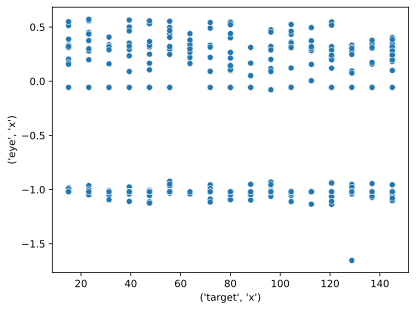

In [73]:
sns.scatterplot(
    data=eye_target_pairs,
    x=('target', 'x'),
    y=('eye', 'x'),
)

In [ ]:
from src.eye_calibration import fit_eye_calibration, apply_eye_calibration
calibration_model = fit_eye_calibration(
    target_positions=eye_target_pairs['target'],
    eye_positions=eye_target_pairs['eye'],
)

rtt_hand_eye_tf_calibrated = (
    rtt_hand_eye_tf
    .pipe(hierarchical_assign,{
        'eye position': lambda df: pd.DataFrame(
            apply_eye_calibration(df['raw eye position'][['x', 'y']], calibration_model),
            index=df.index,
            columns=['x'],
        ),
    })
)
rtt_hand_eye_tf_calibrated

signal                                                                                                                                                 hand position  \
channel                                                                                                                                                            x   
block              trial_id time                   monkey session date trial datetime      trial name                           memory state                           
memory-cst-rtt-dco 6        0 days 00:00:00        Dwight 2025-04-16   2025-04-16 09:27:55 RandomTargetTask-small-reward-memory True   Reach to Center     75.045088   
                            0 days 00:00:00.010000 Dwight 2025-04-16   2025-04-16 09:27:55 RandomTargetTask-small-reward-memory True   Reach to Center     75.229179   
                            0 days 00:00:00.020000 Dwight 2025-04-16   2025-04-16 09:27:55 RandomTargetTask-small-reward-memory True   Reach to Center     75.380848   
                            0 days 00:00:00.030000 Dwight 2025-04-16   2025-04-16 09:27:55 RandomTargetTask-small-reward-memory True   Reach to Center     75.533128   
                            0 days 00:00:00.040000 Dwight 2025-04-16   2025-04-16 09:27:55 RandomTargetTask-small-reward-memory True   Reach to Center     75.716723   
...                                                                                                                                                              ...   
                   302      0 days 00:00:07.250000 Dwight 2025-04-16   2025-04-16 09:57:28 RandomTargetTask-small-reward-memory True   Success             33.432800   
                            0 days 00:00:07.260000 Dwight 2025-04-16   2025-04-16 09:57:28 RandomTargetTask-small-reward-memory True   Success             33.382512   
                            0 days 00:00:07.270000 Dwight 2025-04-16   2025-04-16 09:57:28 RandomTargetTask-small-reward-memory True   Success             33.315145   
                            0 days 00:00:07.280000 Dwight 2025-04-16   2025-04-16 09:57:28 RandomTargetTask-small-reward-memory True   Success             33.266626   
                            0 days 00:00:07.290000 Dwight 2025-04-16   2025-04-16 09:57:28 RandomTargetTask-small-reward-memory True   Success             33.206945   

signal                                                                                                                                                              \
channel                                                                                                                                                          y   
block              trial_id time                   monkey session date trial datetime      trial name                           memory state                         
memory-cst-rtt-dco 6        0 days 00:00:00        Dwight 2025-04-16   2025-04-16 09:27:55 RandomTargetTask-small-reward-memory True   Reach to Center  968.693905   
                            0 days 00:00:00.010000 Dwight 2025-04-16   2025-04-16 09:27:55 RandomTargetTask-small-reward-memory True   Reach to Center  967.941076   
                            0 days 00:00:00.020000 Dwight 2025-04-16   2025-04-16 09:27:55 RandomTargetTask-small-reward-memory True   Reach to Center  967.219968   
                            0 days 00:00:00.030000 Dwight 2025-04-16   2025-04-16 09:27:55 RandomTargetTask-small-reward-memory True   Reach to Center  966.509464   
                            0 days 00:00:00.040000 Dwight 2025-04-16   2025-04-16 09:27:55 RandomTargetTask-small-reward-memory True   Reach to Center  965.817554   
...                                                                                                                                                            ...   
                   302      0 days 00:00:07.250000 Dwight 2025-04-16   2025-04-16 09:57:28 RandomTargetTask-small-reward-memory True   Success          8

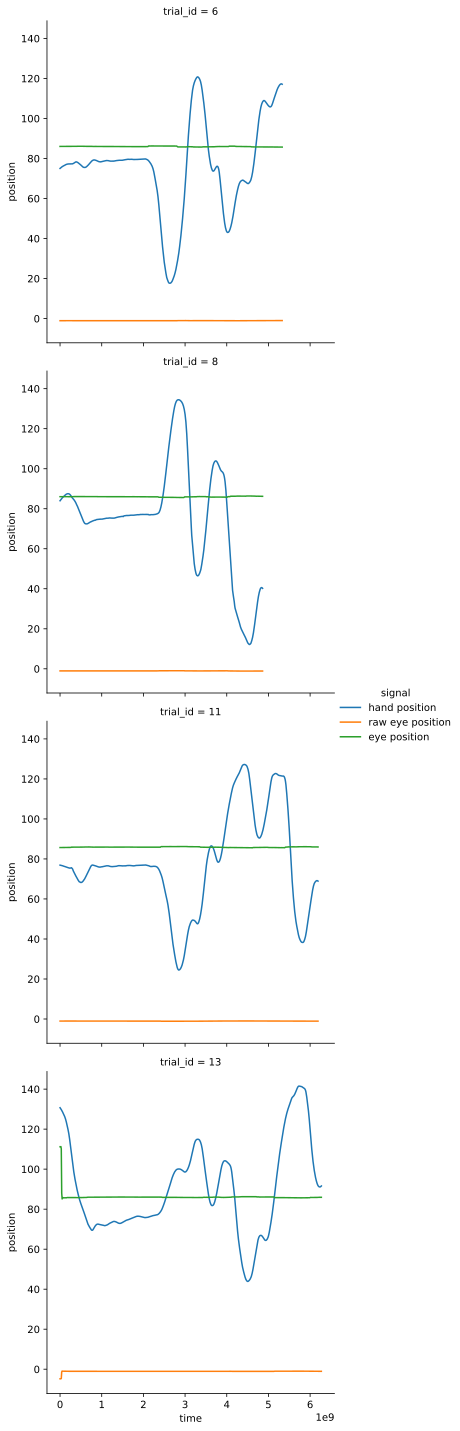

In [ ]:
sns.relplot(
    data=(
        rtt_hand_eye_tf_calibrated
        .xs(axis=1,level='channel',key='x')
        .pipe(multivalue_xs, level='trial_id', keys=[6,8,11,13])
        .stack()
        .to_frame('position')
    ),
    x='time',
    y='position',
    hue='signal',
    kind='line',
    row='trial_id',
)